# Phase 2d: Denoising GAN (DnGAN) — BraTS 2025

Suppresses Gaussian noise while preserving structural gradients.

- Input: 128×128 T1c + Gaussian noise (σ=0.1)
- Loss: MSE + adversarial + gradient penalty
- Progressive: 32→64→128

In [1]:
import os,numpy as np,torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# ══════════════ Denoising Dataset ══════════════
PROC_DIR=r"C:\Users\Admin\processed_data";MOD=1;SIGMA=0.1
class DnDataset(Dataset):
    """Returns (noisy, clean, masks)."""
    def __init__(s,split="train",mod=1,sigma=0.1):
        s.sd=Path(PROC_DIR)/split/"slices";s.md=Path(PROC_DIR)/split/"masks"
        s.files=sorted(s.sd.glob("*.npy"));s.mod=mod;s.sigma=sigma
        print(f"  {split}: {len(s.files)} slices (noise σ={sigma})")
    def __len__(s):return len(s.files)
    def __getitem__(s,i):
        f=s.files[i]
        clean=torch.from_numpy(np.load(str(f)).astype(np.float32)[s.mod:s.mod+1])  # (1,128,128)
        msk=torch.from_numpy(np.load(str(s.md/f.name)).astype(np.float32))          # (4,128,128)
        noisy=(clean+torch.randn_like(clean)*s.sigma).clamp(0,1)
        return noisy,clean,msk
train_ds=DnDataset("train",MOD,SIGMA)
train_dl=DataLoader(train_ds,batch_size=256,shuffle=True,num_workers=0,pin_memory=True)

  train: 8382 slices (noise σ=0.1)


In [3]:
# ══════════════ Shared Blocks ══════════════
class DepthwiseSeparableConv2d(nn.Module):
    def __init__(s,i,o,k=3,st=1,p=1,b=False):super().__init__();s.dw=nn.Conv2d(i,i,k,st,p,groups=i,bias=b);s.pw=nn.Conv2d(i,o,1,bias=b)
    def forward(s,x):return s.pw(s.dw(x))
class DSConvBlock(nn.Module):
    def __init__(s,i,o,k=3,s_=1,act="leaky_relu",bn=True):
        super().__init__()
        layers=[DepthwiseSeparableConv2d(i,o,k,s_,k//2)]
        if bn:layers.append(nn.BatchNorm2d(o))
        a={"relu":nn.ReLU(True),"leaky_relu":nn.LeakyReLU(0.2,True),"none":nn.Identity()}
        layers.append(a.get(act,nn.LeakyReLU(0.2,True)));s.block=nn.Sequential(*layers)
    def forward(s,x):return s.block(x)
class ResidualDSBlock(nn.Module):
    def __init__(s,ch):super().__init__();s.block=nn.Sequential(DSConvBlock(ch,ch),DSConvBlock(ch,ch,act="none"))
    def forward(s,x):return x+s.block(x)
def bce_loss(p,r):return F.binary_cross_entropy_with_logits(p,torch.ones_like(p) if r else torch.zeros_like(p))
def grad_penalty(D,real,fake,dev,lam=10.0):
    a=torch.rand(real.size(0),1,1,1,device=dev);interp=(a*real+(1-a)*fake).requires_grad_(True)
    d=D(interp);g=torch.autograd.grad(d,interp,torch.ones_like(d),create_graph=True,retain_graph=True)[0]
    return lam*((g.view(g.size(0),-1).norm(2,dim=1)-1)**2).mean()
class PSched:
    def __init__(s,lr=2e-4):s.stg=[{"r":32,"e":70,"ls":1.0},{"r":64,"e":38,"ls":0.5},{"r":128,"e":90,"ls":0.25}];s.lr0=lr;s.i=0
    @property
    def res(s):return s.stg[s.i]["r"]
    @property
    def ep(s):return s.stg[s.i]["e"]
    @property
    def lr(s):return s.lr0*s.stg[s.i]["ls"]
    @property
    def n(s):return len(s.stg)
    def adv(s):
        if s.i<len(s.stg)-1:s.i+=1;return True
        return False
    def rsz(s,x):r=s.res;return F.interpolate(x,size=(r,r),mode="bilinear",align_corners=False) if x.shape[-1]!=r else x
    def slr(s,*os):
        for o in os:
            for pg in o.param_groups:pg["lr"]=s.lr
    def __repr__(s):return f"S{s.i+1}/{len(s.stg)} r={s.res} lr={s.lr:.2e}"
print("✓ Ready")

✓ Ready


In [4]:
# ══════════════ DnGAN Architecture ══════════════
class DnGenerator(nn.Module):
    def __init__(s,bf=48,n_res=6):
        super().__init__()
        s.e1=nn.Sequential(DSConvBlock(1,bf),DSConvBlock(bf,bf));s.p1=nn.MaxPool2d(2)
        s.e2=nn.Sequential(DSConvBlock(bf,bf*2),DSConvBlock(bf*2,bf*2));s.p2=nn.MaxPool2d(2)
        s.e3=nn.Sequential(DSConvBlock(bf*2,bf*4),DSConvBlock(bf*4,bf*4));s.p3=nn.MaxPool2d(2)
        s.bot=nn.Sequential(*[ResidualDSBlock(bf*4) for _ in range(n_res)])
        s.u3=nn.ConvTranspose2d(bf*4,bf*2,2,stride=2);s.d3=nn.Sequential(DSConvBlock(bf*4 + bf*2,bf*2),DSConvBlock(bf*2,bf*2))
        s.u2=nn.ConvTranspose2d(bf*2,bf,2,stride=2);  s.d2=nn.Sequential(DSConvBlock(bf*2 + bf,bf),DSConvBlock(bf,bf))
        s.u1=nn.ConvTranspose2d(bf,bf,2,stride=2);    s.d1=nn.Sequential(DSConvBlock(bf*2,bf),DSConvBlock(bf,bf))
        s.out=nn.Sequential(nn.Conv2d(bf,1,1),nn.Sigmoid())
    def forward(s,x):
        e1=s.e1(x);e2=s.e2(s.p1(e1));e3=s.e3(s.p2(e2));b=s.bot(s.p3(e3))
        d3=s.d3(torch.cat([s.u3(b),e3],1));d2=s.d2(torch.cat([s.u2(d3),e2],1));d1=s.d1(torch.cat([s.u1(d2),e1],1))
        return s.out(d1)

class DnDiscriminator(nn.Module):
    def __init__(s,bf=24):
        super().__init__()
        s.model=nn.Sequential(nn.Conv2d(1,bf,4,2,1),nn.LeakyReLU(0.2,True),
            DSConvBlock(bf,bf*2,k=4,s_=2),DSConvBlock(bf*2,bf*4,k=4,s_=2),
            DSConvBlock(bf*4,bf*4,k=4,s_=1),nn.Conv2d(bf*4,1,4,1,1))
    def forward(s,x):return s.model(x)

G=DnGenerator(48,6).to(device);D=DnDiscriminator(24).to(device)
print(f"G:{sum(p.numel() for p in G.parameters()):,}  D:{sum(p.numel() for p in D.parameters()):,}")

G:706,714  D:20,089


In [5]:
SD = r"F:\shn\DnGAN"
os.makedirs(SD, exist_ok=True)

LR=2e-4; LPX=10.0; LGP=10.0
oG=torch.optim.Adam(G.parameters(),lr=LR,betas=(0.5,0.999))
oD=torch.optim.Adam(D.parameters(),lr=LR,betas=(0.5,0.999))
sc=PSched(LR); gl,dl=[],[]

# Fixed batch for consistent per-epoch visualization
_fix_iter = iter(train_dl)
_fix_noisy, _fix_clean, _fix_masks = next(_fix_iter)
fixed_noisy = _fix_noisy[:5].to(device)
fixed_clean = _fix_clean[:5].to(device)

for stage in range(sc.n):
    print(f"\n{'='*50}\n  DnGAN | {sc}\n{'='*50}"); sc.slr(oG,oD)
    for ep in range(sc.ep):
        G.train(); D.train(); eg=ed=0.0
        for noisy,clean,masks in tqdm(train_dl,desc=f"E{ep+1}/{sc.ep}",leave=False):
            noisy=sc.rsz(noisy.to(device)); clean=sc.rsz(clean.to(device))
            denoised=G(noisy).detach()
            lD=bce_loss(D(clean),True)+bce_loss(D(denoised),False)+grad_penalty(D,clean,denoised,device,LGP)
            oD.zero_grad();lD.backward();oD.step()
            denoised=G(noisy)
            lG=bce_loss(D(denoised),True)+LPX*F.mse_loss(denoised,clean)
            oG.zero_grad();lG.backward();oG.step()
            eg+=lG.item();ed+=lD.item()
        nb_=len(train_dl); gl.append(eg/nb_); dl.append(ed/nb_)

        # ── Per-epoch: create folder, save 5 images + weights ──
        epoch_dir = os.path.join(SD, f"stage{stage+1:02d}_epoch{ep+1:03d}")
        os.makedirs(epoch_dir, exist_ok=True)

        # Generate 5 denoised samples from fixed noisy inputs
        G.eval()
        with torch.no_grad():
            fn = sc.rsz(fixed_noisy)
            generated = G(fn).cpu().numpy()   # (5,1,H,W)
            fn_np  = fn.cpu().numpy()
            fc_np  = sc.rsz(fixed_clean).cpu().numpy()

        for i in range(5):
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(fn_np[i, 0], cmap="gray");       axes[0].axis("off"); axes[0].set_title("Noisy input", fontsize=8)
            axes[1].imshow(generated[i, 0], cmap="gray");   axes[1].axis("off"); axes[1].set_title(f"Denoised\nG:{gl[-1]:.4f} D:{dl[-1]:.4f}", fontsize=8)
            axes[2].imshow(fc_np[i, 0], cmap="gray");       axes[2].axis("off"); axes[2].set_title("Clean target", fontsize=8)
            plt.suptitle(f"S{stage+1} E{ep+1} Sample {i+1}", fontsize=9, fontweight="bold")
            plt.tight_layout()
            plt.savefig(os.path.join(epoch_dir, f"sample_{i+1:02d}.png"), dpi=100, bbox_inches="tight")
            plt.close()

        # Save weights inside this epoch folder
        torch.save({
            "G": G.state_dict(),
            "D": D.state_dict(),
            "epoch": ep + 1,
            "stage": stage + 1,
            "g_loss": gl[-1],
            "d_loss": dl[-1],
        }, os.path.join(epoch_dir, "weights.pt"))

        G.train()

        print(f"  Epoch {ep+1:3d}/{sc.ep} | G={gl[-1]:.4f} D={dl[-1]:.4f} | Saved → {epoch_dir}")

    sc.adv()

torch.save(G.state_dict(), f"{SD}/generator_final.pt")
torch.save(D.state_dict(), f"{SD}/discriminator_final.pt")
print("\n✓ DnGAN complete!")
print(f"✓ Per-epoch folders saved to: {SD}")



  DnGAN | S1/3 r=32 lr=2.00e-04


E1/70:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch   1/70 | G=1.3708 D=123.1298 | Saved → F:\shn\DnGAN\stage01_epoch001


E2/70:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch   2/70 | G=0.9191 D=11.4503 | Saved → F:\shn\DnGAN\stage01_epoch002


...

  Epoch  88/90 | G=0.7050 D=1.3906 | Saved → F:\shn\DnGAN\stage03_epoch088


E89/90:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch  89/90 | G=0.7051 D=1.3909 | Saved → F:\shn\DnGAN\stage03_epoch089


E90/90:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch  90/90 | G=0.7051 D=1.3911 | Saved → F:\shn\DnGAN\stage03_epoch090

✓ DnGAN complete!
✓ Per-epoch folders saved to: F:\shn\DnGAN



  TRAINING SUMMARY
Total Epochs Trained: 198
Final Generator Loss:   0.705066
Final Discriminator Loss: 1.391091
Best Generator Loss:    0.704137 (Epoch 109)
Best Discriminator Loss: 1.390551 (Epoch 196)



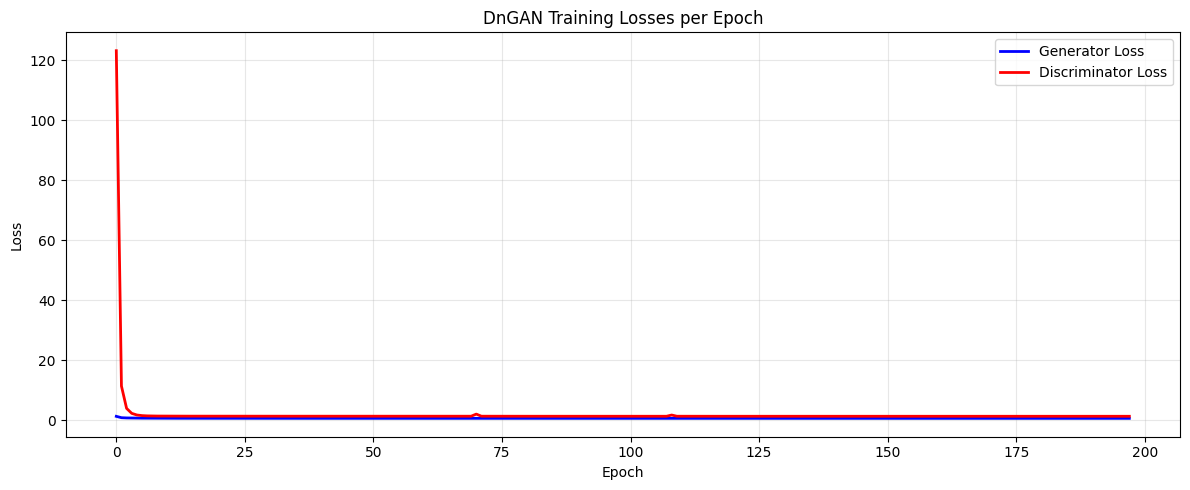

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════ Visualization & Results ══════════════════
print("\n" + "="*70)
print("  TRAINING SUMMARY")
print("="*70)
print(f"Total Epochs Trained: {len(gl)}")
print(f"Final Generator Loss:   {gl[-1]:.6f}")
print(f"Final Discriminator Loss: {dl[-1]:.6f}")
print(f"Best Generator Loss:    {min(gl):.6f} (Epoch {np.argmin(gl)+1})")
print(f"Best Discriminator Loss: {min(dl):.6f} (Epoch {np.argmin(dl)+1})")
print("="*70 + "\n")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gl, label="Generator Loss", linewidth=2, color="blue")
ax.plot(dl, label="Discriminator Loss", linewidth=2, color="red")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("DnGAN Training Losses per Epoch")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SD}/loss.png", dpi=150)
plt.show()


  DENOISING GAN COMPREHENSIVE EVALUATION

✓ Loaded generator from: F:\shn\DnGAN/generator_final.pt
  val: 1662 slices (noise σ=0.1)


Evaluating DnGAN:   0%|          | 0/104 [00:00<?, ?it/s]


  DENOISING GAN EVALUATION SUMMARY  (48 samples, σ=0.1)
  Noisy MSE (baseline)        : 0.007698
  Denoised MSE (↓ better)     : 0.000967
  PSNR (↑ better)             : 30.3663 dB
  SSIM (↑ better)             : 0.853334
  Noise Residual Var (↓ lower): 0.000945
  Edge Preservation (↑ higher): 0.962602
  Denoising Improvement       : +0.006730 MSE reduction



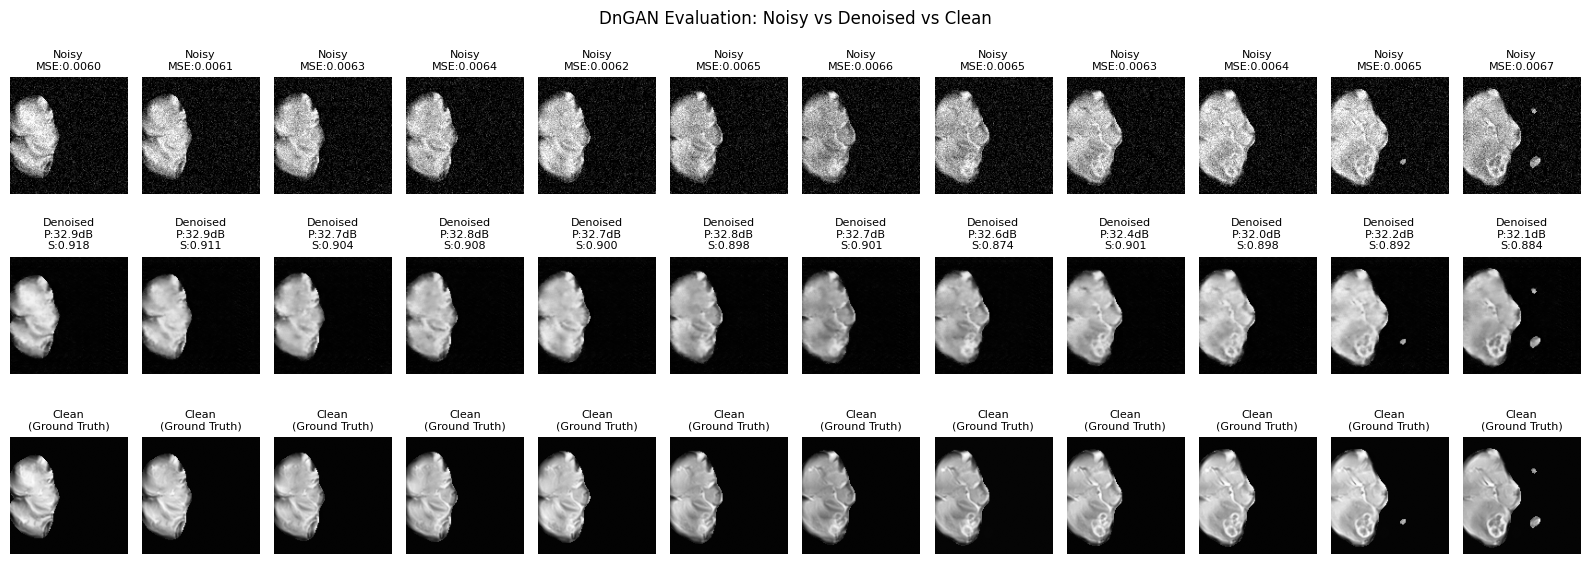

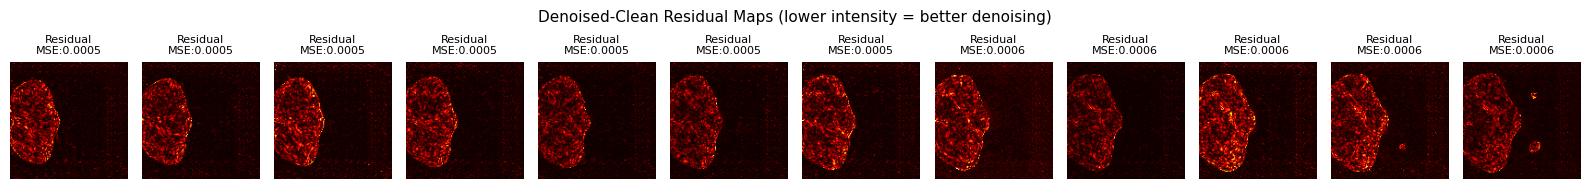

C:\Users\Admin\AppData\Local\Temp\ipykernel_48508\1351113709.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


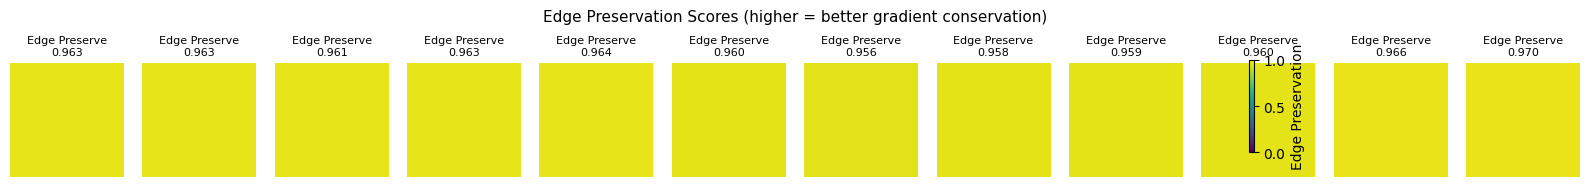

✓ Evaluation complete!
✓ Results saved to: F:\shn\DnGAN\test_outputs
  - comparison.png: Noisy/Denoised/Clean side-by-side
  - residuals.png: Denoising error maps
  - edge_preservation.png: Gradient conservation scores
  - metrics.npy: Full metric dictionary


In [10]:
# ══════════════ COMPREHENSIVE TESTING & EVALUATION (DnGAN) ══════════════════
from skimage.metrics import structural_similarity as ssim_func
from scipy.ndimage import sobel

TEST_OUT = os.path.join(SD, "test_outputs")
os.makedirs(TEST_OUT, exist_ok=True)

print("\n" + "="*70)
print("  DENOISING GAN COMPREHENSIVE EVALUATION")
print("="*70 + "\n")

# Load trained generator
G_test = DnGenerator(48, 6).to(device)
try:
    G_test.load_state_dict(torch.load(f"{SD}/generator_final.pt"))
    print(f"✓ Loaded generator from: {SD}/generator_final.pt")
except Exception as e:
    print(f"Warning: Failed to load generator weights: {e}")
G_test.eval()

# ── Metric Helper Functions for Denoising ──
def compute_psnr(denoised, clean):
    """Peak Signal-to-Noise Ratio (higher is better)."""
    denoised_np = denoised.clip(0, 1)
    clean_np = clean.clip(0, 1)
    mse = np.mean((denoised_np - clean_np) ** 2)
    if mse < 1e-10:
        return 100.0
    max_val = 1.0
    psnr = 20 * np.log10(max_val / np.sqrt(mse))
    return float(psnr)

def compute_ssim(denoised, clean):
    """Structural Similarity Index (higher is better)."""
    denoised_np = denoised.clip(0, 1)
    clean_np = clean.clip(0, 1)
    data_range = 1.0
    try:
        return float(ssim_func(denoised_np, clean_np, data_range=data_range))
    except:
        return np.nan

def compute_mse(denoised, clean):
    """Mean Squared Error (lower is better)."""
    denoised_np = denoised.clip(0, 1)
    clean_np = clean.clip(0, 1)
    return float(np.mean((denoised_np - clean_np) ** 2))

def compute_noise_residual(denoised, clean):
    """Estimate noise residual power (lower = less over-smoothing)."""
    residual = denoised - clean
    return float(np.var(residual))

def compute_edge_preservation(denoised, clean):
    """Measure gradient preservation using Sobel edge detection."""
    try:
        denoised_np = denoised.clip(0, 1)
        clean_np = clean.clip(0, 1)
        
        # Compute Sobel gradients
        gx_d = sobel(denoised_np, axis=0)
        gy_d = sobel(denoised_np, axis=1)
        grad_d = np.sqrt(gx_d**2 + gy_d**2)
        
        gx_c = sobel(clean_np, axis=0)
        gy_c = sobel(clean_np, axis=1)
        grad_c = np.sqrt(gx_c**2 + gy_c**2)
        
        # Cosine similarity of gradients
        dot_prod = np.sum(grad_d * grad_c)
        norm_d = np.sqrt(np.sum(grad_d**2))
        norm_c = np.sqrt(np.sum(grad_c**2))
        
        if norm_d * norm_c < 1e-10:
            return 1.0
        similarity = dot_prod / (norm_d * norm_c)
        return float(np.clip(similarity, 0, 1))
    except:
        return np.nan

def compute_noise_mse(noisy, clean):
    """MSE of noisy image vs clean (baseline)."""
    noisy_np = noisy.clip(0, 1)
    clean_np = clean.clip(0, 1)
    return float(np.mean((noisy_np - clean_np) ** 2))

# ── Test Dataloader ──
val_ds = DnDataset("val", MOD, SIGMA)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# ── Evaluation Loop ──
metrics = {
    "psnr": [], "ssim": [], "mse": [], "noise_residual": [],
    "edge_preservation": [], "noisy_mse": []
}
all_noisy, all_denoised, all_clean, all_masks = [], [], [], []
count = 0

with torch.no_grad():
    for batch_idx, (noisy, clean, masks) in enumerate(tqdm(val_dl, desc="Evaluating DnGAN", leave=True)):
        noisy_t = sc.rsz(noisy.to(device))
        clean_t = sc.rsz(clean.to(device))
        
        # Denoise
        denoised_t = G_test(noisy_t)

        noisy_np = noisy_t.cpu().numpy()
        denoised_np = denoised_t.cpu().numpy()
        clean_np = clean_t.cpu().numpy()
        masks_np = masks.numpy()

        for i in range(noisy_np.shape[0]):
            noisy_img = noisy_np[i, 0]
            denoised_img = denoised_np[i, 0]
            clean_img = clean_np[i, 0]
            mask = masks_np[i]

            # Compute metrics
            metrics["psnr"].append(compute_psnr(denoised_img, clean_img))
            metrics["ssim"].append(compute_ssim(denoised_img, clean_img))
            metrics["mse"].append(compute_mse(denoised_img, clean_img))
            metrics["noise_residual"].append(compute_noise_residual(denoised_img, clean_img))
            metrics["edge_preservation"].append(compute_edge_preservation(denoised_img, clean_img))
            metrics["noisy_mse"].append(compute_noise_mse(noisy_img, clean_img))

            # Store for visualization
            all_noisy.append(noisy_img)
            all_denoised.append(denoised_img)
            all_clean.append(clean_img)
            all_masks.append(mask)
            count += 1

        if count >= 48:  # Evaluate on ~48 samples
            break

# ── Summary Statistics ──
def safe_mean(lst):
    vals = [v for v in lst if not np.isnan(v)]
    return np.mean(vals) if vals else np.nan

print(f"\n{'='*70}")
print(f"  DENOISING GAN EVALUATION SUMMARY  ({count} samples, σ={SIGMA})")
print(f"{'='*70}")
print(f"  Noisy MSE (baseline)        : {safe_mean(metrics['noisy_mse']):.6f}")
print(f"  Denoised MSE (↓ better)     : {safe_mean(metrics['mse']):.6f}")
print(f"  PSNR (↑ better)             : {safe_mean(metrics['psnr']):.4f} dB")
print(f"  SSIM (↑ better)             : {safe_mean(metrics['ssim']):.6f}")
print(f"  Noise Residual Var (↓ lower): {safe_mean(metrics['noise_residual']):.6f}")
print(f"  Edge Preservation (↑ higher): {safe_mean(metrics['edge_preservation']):.6f}")
denoise_improvement = safe_mean(metrics['noisy_mse']) - safe_mean(metrics['mse'])
print(f"  Denoising Improvement       : {denoise_improvement:+.6f} MSE reduction")
print(f"{'='*70}\n")

# ── Visualization: Noisy vs Denoised vs Clean ──
n_show = min(12, count)
fig, axes = plt.subplots(3, n_show, figsize=(16, 6))
for i in range(n_show):
    axes[0, i].imshow(all_noisy[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Noisy\nMSE:{metrics['noisy_mse'][i]:.4f}", fontsize=8)
    axes[0, i].axis("off")
    
    axes[1, i].imshow(all_denoised[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Denoised\nP:{metrics['psnr'][i]:.1f}dB\nS:{metrics['ssim'][i]:.3f}", fontsize=8)
    axes[1, i].axis("off")
    
    axes[2, i].imshow(all_clean[i], cmap="gray", vmin=0, vmax=1)
    axes[2, i].set_title(f"Clean\n(Ground Truth)", fontsize=8)
    axes[2, i].axis("off")

fig.suptitle("DnGAN Evaluation: Noisy vs Denoised vs Clean", fontsize=12, y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT, "comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Residual visualization (Denoised vs Clean) ──
fig, axes = plt.subplots(1, n_show, figsize=(16, 2))
for i in range(n_show):
    residual = np.abs(all_denoised[i] - all_clean[i])
    im = axes[i].imshow(residual, cmap="hot")
    axes[i].set_title(f"Residual\nMSE:{metrics['mse'][i]:.4f}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Denoised-Clean Residual Maps (lower intensity = better denoising)", fontsize=11, y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT, "residuals.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Edge preservation heatmap ──
fig, axes = plt.subplots(1, n_show, figsize=(16, 2))
for i in range(n_show):
    ep_score = metrics['edge_preservation'][i]
    # Create visual representation of edge preservation score
    edge_vis = np.full_like(all_clean[i], ep_score)
    im = axes[i].imshow(edge_vis, cmap="viridis", vmin=0, vmax=1)
    axes[i].set_title(f"Edge Preserve\n{ep_score:.3f}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Edge Preservation Scores (higher = better gradient conservation)", fontsize=11, y=0.98)
plt.colorbar(im, ax=axes, label="Edge Preservation", shrink=0.6)
plt.tight_layout()
plt.savefig(os.path.join(TEST_OUT, "edge_preservation.png"), dpi=150, bbox_inches="tight")
plt.show()

# Save metrics to file
np.save(os.path.join(TEST_OUT, "metrics.npy"), metrics)
print(f"✓ Evaluation complete!")
print(f"✓ Results saved to: {TEST_OUT}")
print(f"  - comparison.png: Noisy/Denoised/Clean side-by-side")
print(f"  - residuals.png: Denoising error maps")
print(f"  - edge_preservation.png: Gradient conservation scores")
print(f"  - metrics.npy: Full metric dictionary")